# 02 — Exploratory Data Analysis

**What this notebook does:** Provides a comprehensive overview of the 490 k-shot Understat dataset — volume breakdowns, goal rates, shot locations, xG profile, and player-level sample sizes.

**Key output:** Confirms the dataset is clean and representative. Raw statistics referenced throughout the final report.


In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd
import numpy as np
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
from pathlib import Path
OUTPUTS_DIR = Path('../data/outputs')
PROCESSED_DIR = Path('../data/processed')
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
from src.scraper import load_understat_cache

## 2.1  Load raw data

In [2]:
raw = load_understat_cache()
print(f"Total shots (penalties excluded): {len(raw):,}")
print(f"Leagues  : {sorted(raw['league'].unique())}")
print(f"Seasons  : {sorted(raw['season'].unique())}")
print(f"Players  : {raw['player_id'].nunique():,} unique")
print(f"Goal rate: {(raw['result'] == 'Goal').mean():.3f}")
raw.head()


Total shots (penalties excluded): 490,204
Leagues  : ['Bundesliga', 'EPL', 'La_liga', 'Ligue_1', 'Serie_A']
Seasons  : [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Players  : 7,253 unique
Goal rate: 0.098


,id,minute,result,X,Y,xG,player,h_a,player_id,situation,...,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction,league
0,24339,11,SavedShot,0.903,0.239,0.034118,Thomas Müller,h,224,OpenPlay,...,RightFoot,5447,Bayern Munich,Wolfsburg,2,1,2014-08-22 19:30:00,Philipp Lahm,Chipped,Bundesliga
1,24340,17,SavedShot,0.852,0.277,0.030941,Arjen Robben,h,392,OpenPlay,...,LeftFoot,5447,Bayern Munich,Wolfsburg,2,1,2014-08-22 19:30:00,Philipp Lahm,Pass,Bundesliga
2,24342,26,BlockedShot,0.803,0.277,0.021718,Arjen Robben,h,392,OpenPlay,...,LeftFoot,5447,Bayern Munich,Wolfsburg,2,1,2014-08-22 19:30:00,Holger Badstuber,Chipped,Bundesliga
3,24343,28,SavedShot,0.871,0.324,0.050345,Thomas Müller,h,224,OpenPlay,...,LeftFoot,5447,Bayern Munich,Wolfsburg,2,1,2014-08-22 19:30:00,NaN,NaN,Bundesliga
4,24344,29,SavedShot,0.918,0.531,0.111078,Robert Lewandowski,h,227,OpenPlay,...,RightFoot,5447,Bayern Munich,Wolfsburg,2,1,2014-08-22 19:30:00,Gianluca Gaudino,Chipped,Bundesliga


## 2.2  Shot volume by league and season

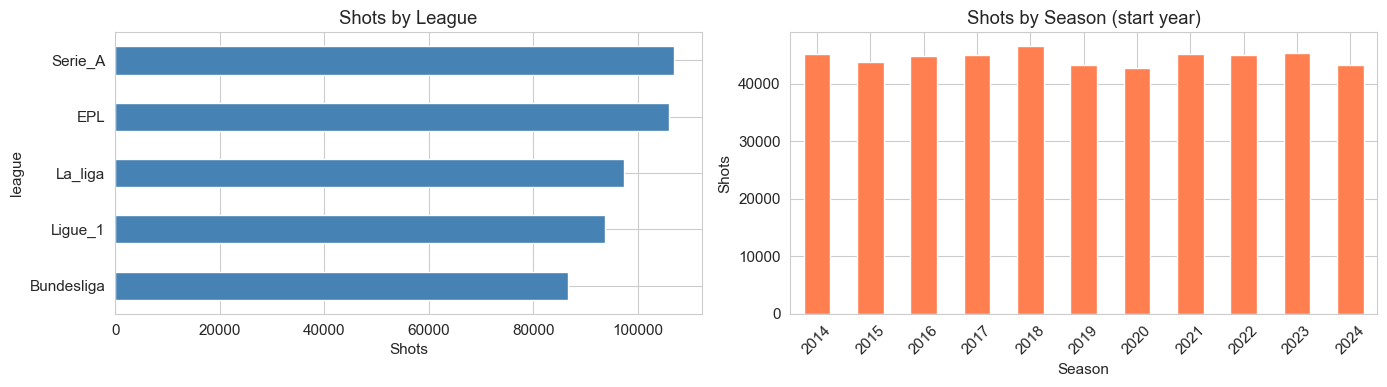

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

raw['league'].value_counts().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Shots by League'); axes[0].set_xlabel('Shots')

raw.groupby('season').size().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Shots by Season (start year)')
axes[1].set_xlabel('Season'); axes[1].set_ylabel('Shots')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_volume.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.3  `lastAction` distribution — the key proxy features for clustering

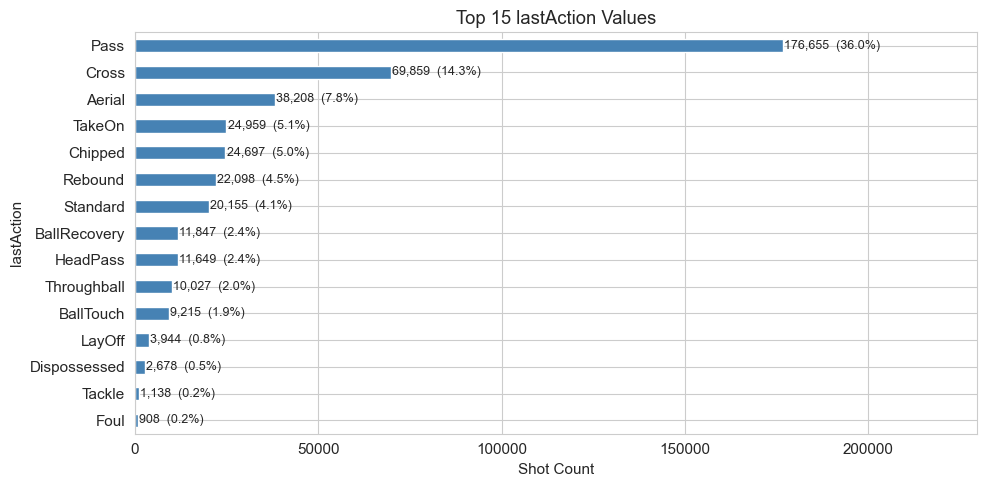


Raw counts:
lastAction
Pass            176655
Cross            69859
Aerial           38208
TakeOn           24959
Chipped          24697
Rebound          22098
Standard         20155
BallRecovery     11847
HeadPass         11649
Throughball      10027
BallTouch         9215
LayOff            3944
Dispossessed      2678
Tackle            1138
Foul               908


In [4]:
top_la = raw['lastAction'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_la.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 lastAction Values'); ax.set_xlabel('Shot Count')
for i, (name, v) in enumerate(top_la.sort_values().items()):
    ax.text(v + 300, i, f'{v:,}  ({v/len(raw)*100:.1f}%)', va='center', fontsize=9)
ax.set_xlim(0, top_la.max() * 1.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_lastaction.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRaw counts:")
print(top_la.to_string())


## 2.4  Goal rate by situation and body part

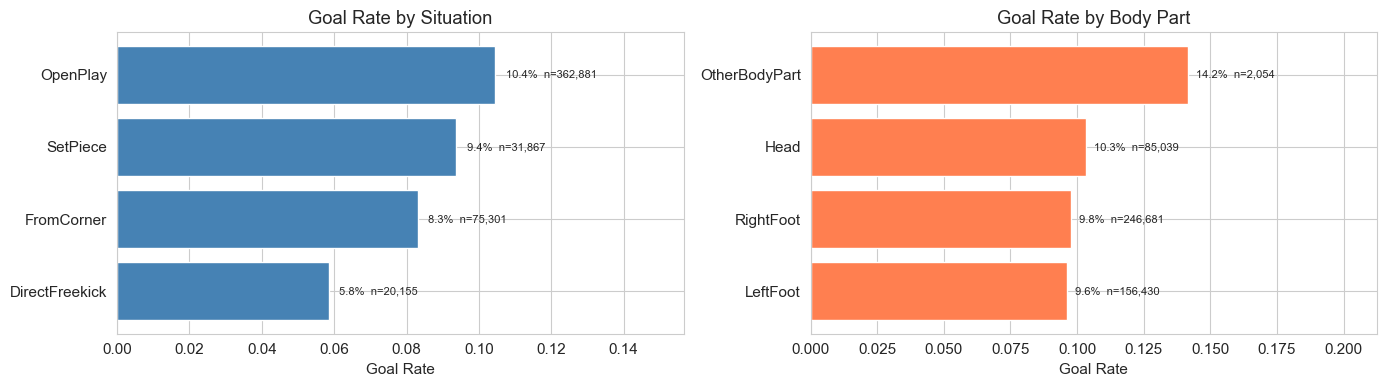

In [5]:
raw['is_goal'] = (raw['result'] == 'Goal').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, title, colour in [
    (axes[0], 'situation', 'Goal Rate by Situation', 'steelblue'),
    (axes[1], 'shotType',  'Goal Rate by Body Part',  'coral'),
]:
    g = raw.groupby(col)['is_goal'].agg(['mean', 'count']).sort_values('mean')
    bars = ax.barh(g.index, g['mean'], color=colour, edgecolor='white')
    for bar, (_, row) in zip(bars, g.iterrows()):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                f"{row['mean']:.1%}  n={int(row['count']):,}", va='center', fontsize=8)
    ax.set_title(title); ax.set_xlabel('Goal Rate')
    ax.set_xlim(0, g['mean'].max() * 1.5)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_goal_rates.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.5  Shot location heatmap (Understat coordinate space, 0–100)

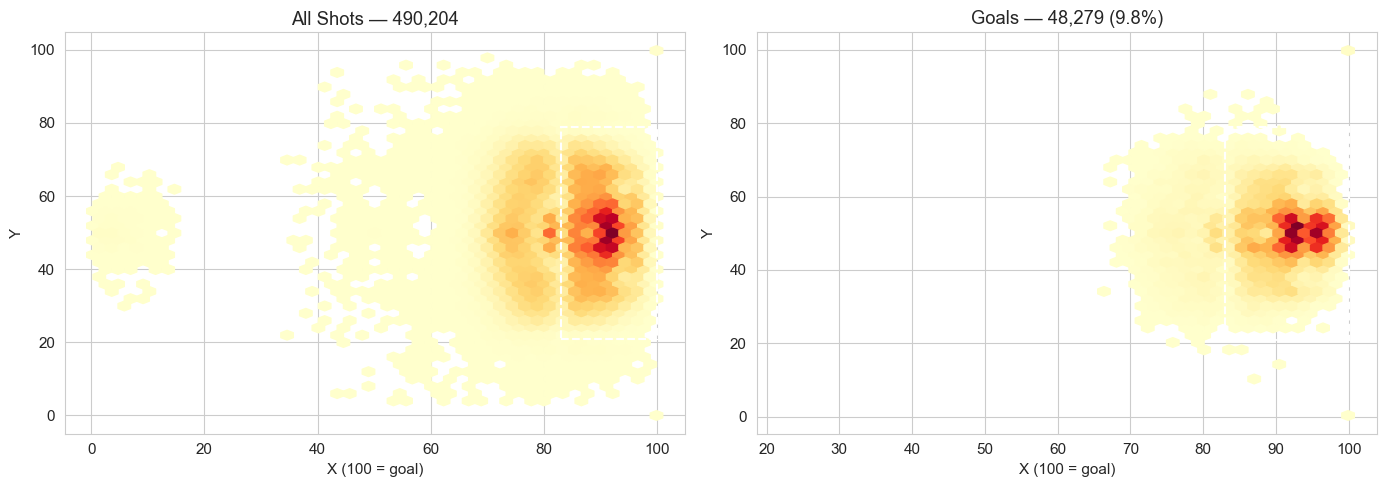

In [6]:
goals = raw[raw['result'] == 'Goal']
x_all  = pd.to_numeric(raw['X'],  errors='coerce') * 100
y_all  = pd.to_numeric(raw['Y'],  errors='coerce') * 100
x_goal = pd.to_numeric(goals['X'], errors='coerce') * 100
y_goal = pd.to_numeric(goals['Y'], errors='coerce') * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, xs, ys, title in [
    (axes[0], x_all,  y_all,  f'All Shots — {len(raw):,}'),
    (axes[1], x_goal, y_goal, f'Goals — {len(goals):,} ({len(goals)/len(raw)*100:.1f}%)'),
]:
    ax.hexbin(xs, ys, gridsize=45, cmap='YlOrRd', mincnt=3)
    # Penalty box outline (approx)
    rect = patches.Rectangle((83, 21), 17, 58, linewidth=1.5,
                               edgecolor='white', facecolor='none', linestyle='--')
    ax.add_patch(rect)
    ax.set_title(title); ax.set_xlabel('X (100 = goal)'); ax.set_ylabel('Y')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_shot_map.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.6  Understat xG distribution

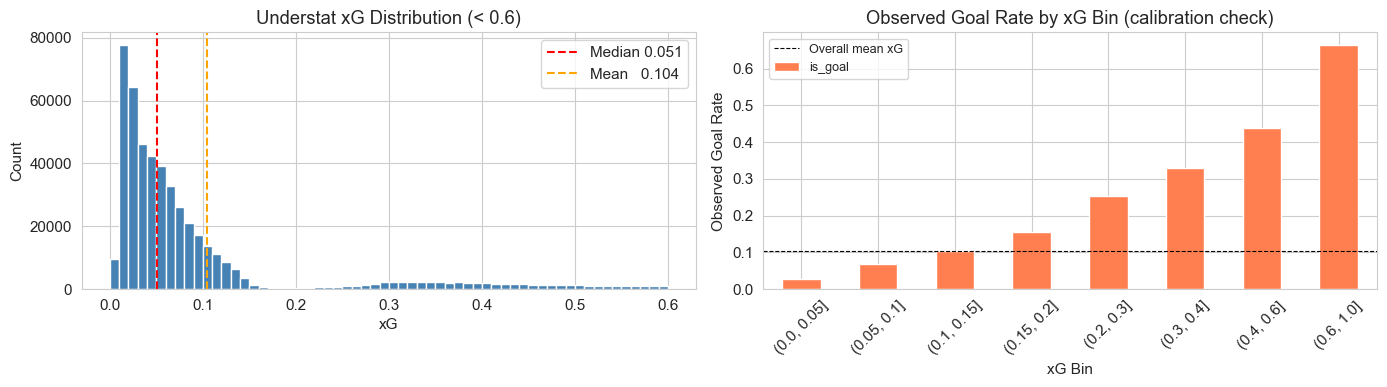

xG summary:
count    490204.0000
mean          0.1041
std           0.1475
min           0.0000
25%           0.0248
50%           0.0512
75%           0.0944
max           0.9799
Name: xG, dtype: float64


In [7]:
xg = pd.to_numeric(raw['xG'], errors='coerce').dropna()
raw['xg_bin'] = pd.cut(xg, bins=[0, .05, .1, .15, .2, .3, .4, .6, 1.0])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(xg[xg < 0.6], bins=60, edgecolor='white', color='steelblue')
axes[0].axvline(xg.median(), color='red',    linestyle='--', label=f'Median {xg.median():.3f}')
axes[0].axvline(xg.mean(),   color='orange', linestyle='--', label=f'Mean   {xg.mean():.3f}')
axes[0].set_title('Understat xG Distribution (< 0.6)')
axes[0].set_xlabel('xG'); axes[0].set_ylabel('Count'); axes[0].legend()

raw.groupby('xg_bin', observed=True)['is_goal'].mean().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Observed Goal Rate by xG Bin (calibration check)')
axes[1].set_xlabel('xG Bin'); axes[1].set_ylabel('Observed Goal Rate')
axes[1].tick_params(axis='x', rotation=45)
axes[1].plot(axes[1].get_xlim(), [xg.mean(), xg.mean()], 'k--', lw=0.8, label='Overall mean xG')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_xg_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"xG summary:\n{xg.describe().round(4)}")


## 2.7  Player shot volume (min-threshold context)

Unique players         : 7,186
Median shots/player    : 26
Players with ≥ 15 shots: 4,459
Players with ≥100 shots: 1,483


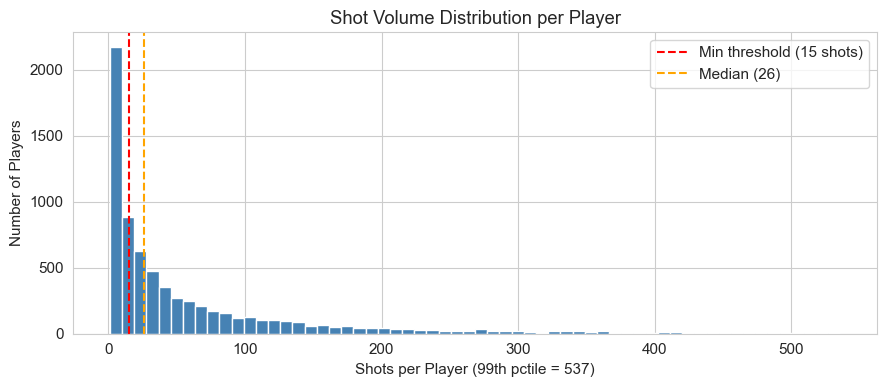

In [8]:
shots_pp = raw['player'].value_counts()
print(f"Unique players         : {len(shots_pp):,}")
print(f"Median shots/player    : {shots_pp.median():.0f}")
print(f"Players with ≥ 15 shots: {(shots_pp >= 15).sum():,}")
print(f"Players with ≥100 shots: {(shots_pp >= 100).sum():,}")

fig, ax = plt.subplots(figsize=(9, 4))
cutoff = shots_pp.quantile(0.99)
ax.hist(shots_pp[shots_pp <= cutoff], bins=60, edgecolor='white', color='steelblue')
ax.axvline(15, color='red',    linestyle='--', lw=1.5, label='Min threshold (15 shots)')
ax.axvline(shots_pp.median(), color='orange', linestyle='--',
           label=f'Median ({shots_pp.median():.0f})')
ax.set_xlabel(f'Shots per Player (99th pctile = {cutoff:.0f})')
ax.set_ylabel('Number of Players')
ax.set_title('Shot Volume Distribution per Player')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_player_volume.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary

| Metric | Value |
|---|---|
| Total shots (penalties excluded) | 490,204 |
| Leagues | EPL, La Liga, Bundesliga, Serie A, Ligue 1 |
| Seasons | 2014/15 – 2024/25 (11 seasons) |
| Unique players | ~7,000 |
| Goal rate | ~9.8% |
| Most common lastAction | Pass (35%), Cross (12%), Aerial (9%) |
| Highest-xG situation | OpenPlay + inside box |

The dataset is clean, covers all intended competitions and seasons, and shows sensible goal rates by situation and body part.
